# Illustration of Pre-trained SAM 


In [5]:
import requests

from PIL import Image

import torch
import torchvision 
from torchvision import transforms
from torchvision.io import decode_image

import matplotlib.pyplot as plt
import numpy as np


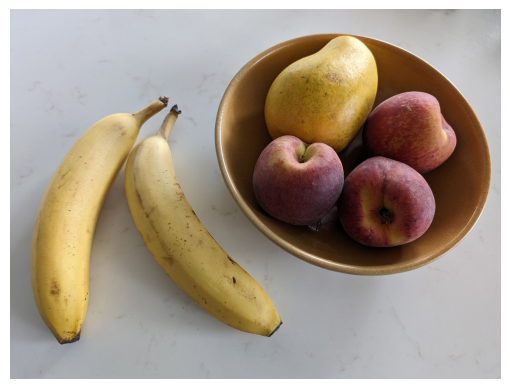

In [12]:
# Load single image

img_url = "https://s3.amazonaws.com/keras.io/img/book/fruits.jpg"

response = requests.get("https://s3.amazonaws.com/keras.io/img/book/fruits.jpg", stream = True)
img = Image.open(response.raw)

plt.imshow(img)
plt.axis('off')
plt.show()

In [34]:
# Inspecting img
transform = transforms.Compose([
    transforms.ToTensor(), 
    ])
img_tensor = transform(img)
img_tensor.shape

torch.Size([3, 1054, 1400])

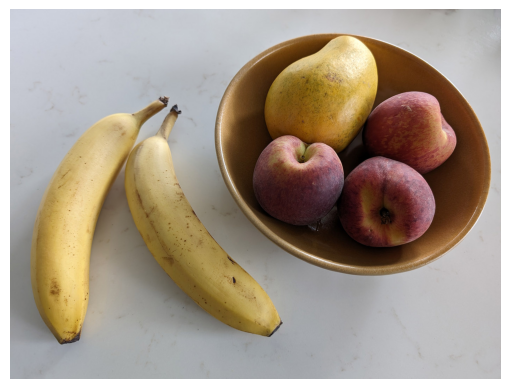

In [35]:
plot_ready_img =  img_tensor.permute(1,2,0)
plt.imshow(plot_ready_img)
plt.axis('off')
plt.show()

## Works to do
1. Prepare the test image to test
2. Create helper functions to show image, mask, points and box for illustration purpose
3. Use SAM to predict the mask using the images, points and labels as inputs
4. Prompt the model with target box for segmentation 

In [51]:
import torch.nn.functional as F

def resize_and_pad(x, target_size = 1024):
    is_batched = x.dim() == 4
    if not is_batched:
        x = x.unsqueeze(0)
    
    _, _ , h, w = x.shape

    scale = target_size / max(h, w)
    new_h = int(scale * h)
    new_w = int(scale * w)

    x_resized = F.interpolate(x, (new_h, new_w), mode = 'bilinear', align_corners=False)

    pad_h = target_size - new_h
    pad_w = target_size - new_w

    pad_left = pad_w // 2
    pad_right = pad_w - pad_left
    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top

    padded_image = F.pad(x_resized, (pad_left, pad_right, pad_top, pad_bottom), mode = 'constant',  value = 0)

    return padded_image


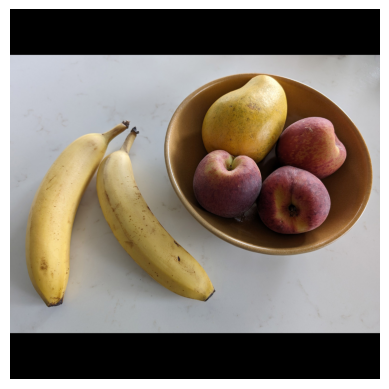

torch.Size([1024, 1024, 3])


In [52]:
padded_image = resize_and_pad(img_tensor).squeeze(0).permute(1, 2, 0)
plt.imshow(padded_image)
plt.axis('off')
plt.show()

print(padded_image.shape)

In [55]:
# Utilities for showing images, boxes, mask and points

def show_image(image, ax):
    ax.imshow(image.detach().cpu().numpy())

def show_mask(mask, ax):
    h, w, _= mask.shape

    color = [30255, 144/255, 255/255, 0/6]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1,1,-1)
    ax.imshow(mask_image)

def show_points(points, ax):
    x, y = points[:, 0], points[:, 1]
    ax.scatter(x,y, c ='green', marker = '*', s= 375, ec = 'white', lw = 1.25)

def show_box(box, ax):
    if torch.is_tensor(box):
        box = box.detach().cpu().numpy()
    
    box = box.reshape(-1)
    x0, y0 = box[0], box[1]
    w = box[2] - x0
    h = box[3] - y0
    ax.add_patch(plt.Rectangle((x0, y0), w, h, ec = 'purple', fc = 'none', lw = 2))


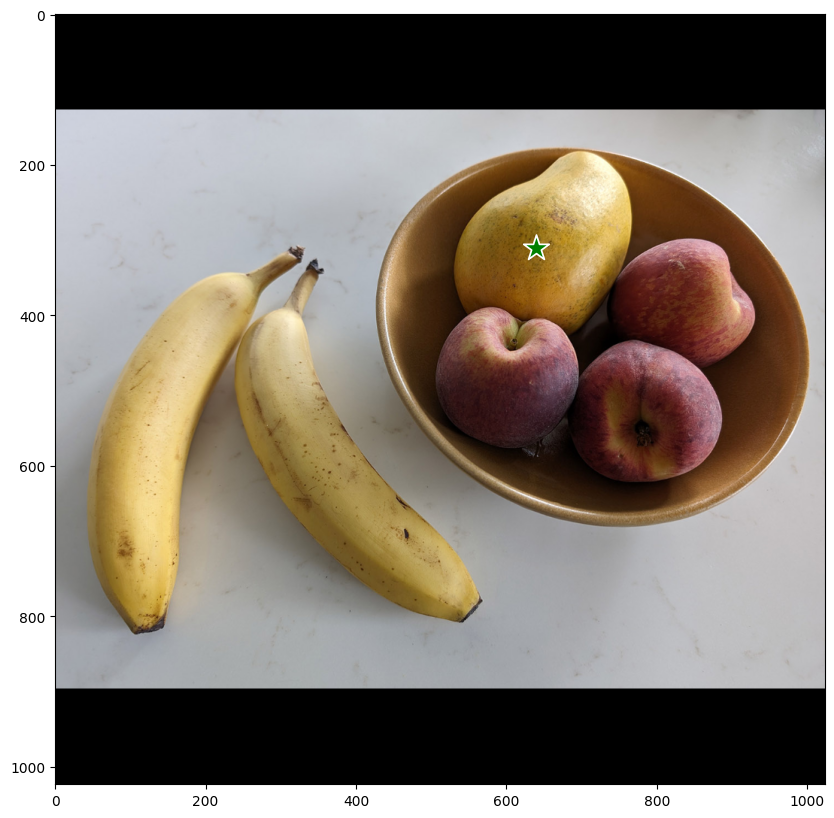

In [60]:
input_point = np.array([[640, 310]])

plt.figure(figsize = (10, 10))
show_image(padded_image, plt.gca())
show_points(input_point, plt.gca())

In [ ]:
# Loading the Segment Anything Model

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model_type = 'vit_h'
checkpoint_path = "sam_vit_h_4b8939.pth"

sam = sam_model_registry[model_type](chekpoint = checkpoint_path)
sam.to(device)

